Some simple code for displaying some of the slices and their segmentation masks

In [1]:
import sys
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
plt.style.use('default')

sys.path.append(os.path.abspath(".."))

In [2]:
from src.data import get_samples_df
from src.data import DicomDataset, VisualParams
from src.brain_transforms import get_spatial_transform_list, get_color_transform_list

In [3]:
data_path = Path('/data/vision/polina/users/marcusbl/bin_class/label_sessions_data/label_session_3-11/final.csv')

In [4]:
vis_params = VisualParams(display_method = 'stack2', 
                    norm_method = 'min-max', 
                    masked_norm = True,
                    percentile_norm   = .02)

data_samples_df, person_ids = get_samples_df(data_path, include_edges = False)
train_dataset = DicomDataset(data_samples_df, vis_params = vis_params, person_ids = person_ids, summarize_name = 'bleh bleh')


Full Dataset has 6813 samples
label
0    5690
1    1123
Name: count, dtype: Int64
bleh bleh
----------------
{'pos': 1123, 'neg': 5690, 'total': 6813}
----------------



/data/vision/polina/users/marcusbl/bin_class/src/data.py:209: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new['label'] = df_new[label_col_name].astype('Int64')


In [5]:
idxs = [80, 30, 50, 99]

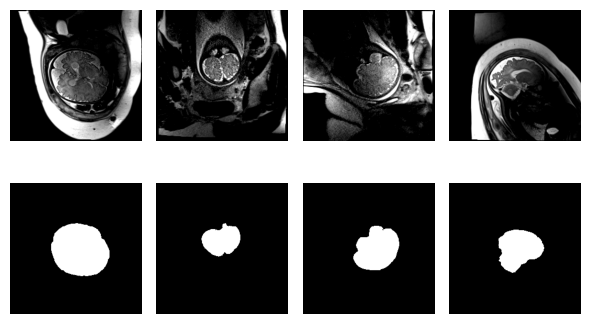

In [6]:
fig, ax = plt.subplots(nrows = 2, ncols = 4, figsize = (6,4))
for i, idx in enumerate(idxs):
    img, mask = train_dataset[idx][0][0, :, :], train_dataset[idx][1]
    ax[0, i].imshow(img, cmap='grey', vmin=0, vmax = 1)
    ax[1, i].imshow(mask, cmap='grey', vmin=0, vmax = 1)

    ax[0, i].axis("off")
    ax[1, i].axis("off")

plt.tight_layout()
plt.savefig('segmentation.png')

In [7]:
def apply_aug(dataset: DicomDataset, method = ''):
    augmentation_list = []
    
    if 's' in method:
        print("Applying Spatital Augmentations")
        augmentation_list.extend(get_spatial_transform_list().copy())
    if 'c' in method:
        print("Applying Color Augmentations")
        augmentation_list.extend(get_color_transform_list().copy())

    dataset.set_aug(augmentation_list)

In [8]:
idxs = [80, 30, 50, 99]
aug_options = ['', 's', 'c']

Applying Spatital Augmentations
Applying Color Augmentations


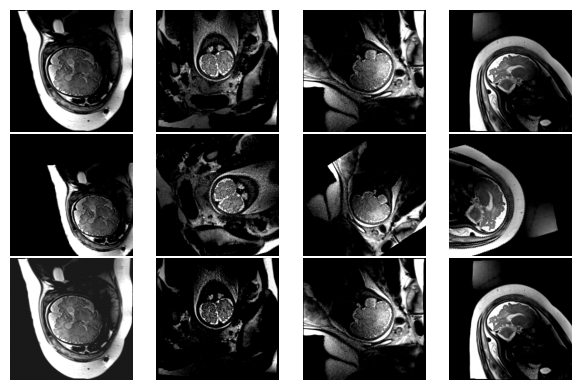

In [9]:
fig, ax = plt.subplots(nrows = len(aug_options), ncols = 4, figsize = (6,4))

for i, aug_method in enumerate(aug_options):
    apply_aug(train_dataset, aug_method)
    for j, idx in enumerate(idxs):
        img, mask = train_dataset[idx][0][0, :, :], train_dataset[idx][1]
        ax[i, j].imshow(img, cmap='grey', vmin=0, vmax = 1)

        ax[i, j].axis("off")

    plt.tight_layout()


Displaying Hydrocephelus

In [10]:
hydro_path = Path('/data/vision/polina/users/marcusbl/data/anon-00093-7-8-2015/stack_4/clean/dicoms.npy')
mask_path = Path('/data/vision/polina/users/marcusbl/data/anon-00093-7-8-2015/stack_4/clean/masks.npy')

scan_data = np.load(hydro_path)
mask_data = np.load(mask_path)

In [11]:
scan_data.shape

(256, 256, 55)

In [12]:
def minmax_normalize(scan, mask=None, percentile=0.01):
    """
    scan: (H, W)
    mask: (H, W) boolean (optional)
    """

    scan = scan.astype(np.float32)

    if mask is not None and mask.sum() > 0:
        mask = mask.astype(bool)
        nz_values = scan[mask]
    else:
        nz_values = scan[scan > 0]

    if nz_values.size == 0:
        return scan

    scan_min = np.quantile(nz_values, percentile)
    scan_max = np.quantile(nz_values, 1 - percentile)

    new_scan = (scan - scan_min) / (scan_max - scan_min + 1e-6)
    return np.clip(new_scan, 0, 1)

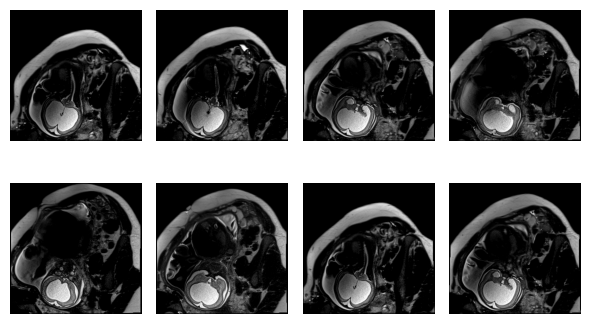

In [13]:
fig, ax = plt.subplots(nrows=2, ncols=4, figsize=(6, 4))

idxs = np.random.choice(range(20, 40), size = 8)
idxs = [20, 22, 28, 30, 38, 32, 20, 28]

for i, idx in enumerate(idxs):
    img = minmax_normalize(scan_data[:, :, idx], mask_data[:, :, idx])

    row = i // 4
    col = i % 4

    ax[row, col].imshow(img, cmap='gray', vmin=0, vmax=1)
    ax[row, col].axis("off")

plt.tight_layout()
plt.savefig('hydro.png')

# Diff. Normalization Strategies

In [64]:
idxs = [955, 102, 435, 50]

In [76]:
def display_datasets(
    dataset: DicomDataset,
    vp_dict_list: list[dict],
    idxs: list[int],
    sup_title: str,
    fpath: Path | None = None,
    hist_fpath: Path | None = None,
):
    first_idx = idxs[0]

    # -----------------------------
    # Figure 1: images ONLY
    # -----------------------------
    fig_img, ax_img = plt.subplots(
        nrows=len(idxs),
        ncols=len(vp_dict_list),
        figsize=(5 * len(vp_dict_list), 3 * len(idxs) + 2),
    )

    # Ensure 2D axes
    if len(idxs) == 1 and len(vp_dict_list) == 1:
        ax_img = np.array([[ax_img]])
    elif len(idxs) == 1:
        ax_img = np.array([ax_img])
    elif len(vp_dict_list) == 1:
        ax_img = np.array([[a] for a in ax_img])

    # Column titles
    for j, params in enumerate(vp_dict_list):
        ax_img[0, j].set_title(params["title"], fontsize=12)

    # Plot images
    for row, idx in enumerate(idxs):
        for col, p in enumerate(vp_dict_list):
            vp = VisualParams(**{k: v for k, v in p.items() if k != "title"})
            dataset.set_vis_params(vp)

            ax_img[row, col].imshow(
                dataset[idx][0][0],
                cmap="gray",
                # vmin=0,
                # vmax=1,
            )
            ax_img[row, col].set_xticks([])
            ax_img[row, col].set_yticks([])

    fig_img.suptitle(sup_title, fontsize=20, weight="bold", y=1.01)    
    plt.tight_layout()

    if fpath is not None:
        fig_img.savefig(fpath, bbox_inches="tight")

    # -----------------------------
    # Figure 2: histograms ONLY (first idx)
    # -----------------------------
    fig_hist, ax_hist = plt.subplots(
        nrows=1,
        ncols=len(vp_dict_list),
        figsize=(5 * len(vp_dict_list), 3),
    )

    if len(vp_dict_list) == 1:
        ax_hist = [ax_hist]

    for j, p in enumerate(vp_dict_list):
        vp = VisualParams(**{k: v for k, v in p.items() if k != "title"})
        dataset.set_vis_params(vp)

        ax_hist[j].hist(
            dataset[first_idx][0][0].flatten(),
            bins=50,
            color="gray",
        )
        ax_hist[j].set_title(f"{p['title']}", fontsize=12)
        ax_hist[j].set_xlabel("Pixel value")
        ax_hist[j].set_ylabel("Count")
        ax_hist[j].grid(alpha=0.2)

    fig_hist.suptitle("Histograms", fontsize=16, weight="bold")
    plt.tight_layout()

    if hist_fpath is not None:
        fig_hist.savefig(hist_fpath, bbox_inches="tight")

    plt.show()

In [77]:
norm_params = [
    {'display_method': None, 'norm_method':'peak-squash', 'masked_norm': True, 'percentile_norm': 0, 'title': 'peak squash (masked)'},
    {'display_method': None, 'norm_method':'min-max', 'masked_norm': False, 'percentile_norm': 0, 'title': 'min-max'},
    {'display_method': None, 'norm_method':'min-max', 'masked_norm': False, 'percentile_norm': 0.02, 'title': 'min-max (perc = 0.02)'},
    {'display_method': None, 'norm_method':'min-max', 'masked_norm': True, 'percentile_norm': 0, 'title': 'min-max (masked)'},
    {'display_method': None, 'norm_method':'min-max', 'masked_norm': True, 'percentile_norm': 0.02, 'title': 'min-max (masked; perc = 0.02)'},
]

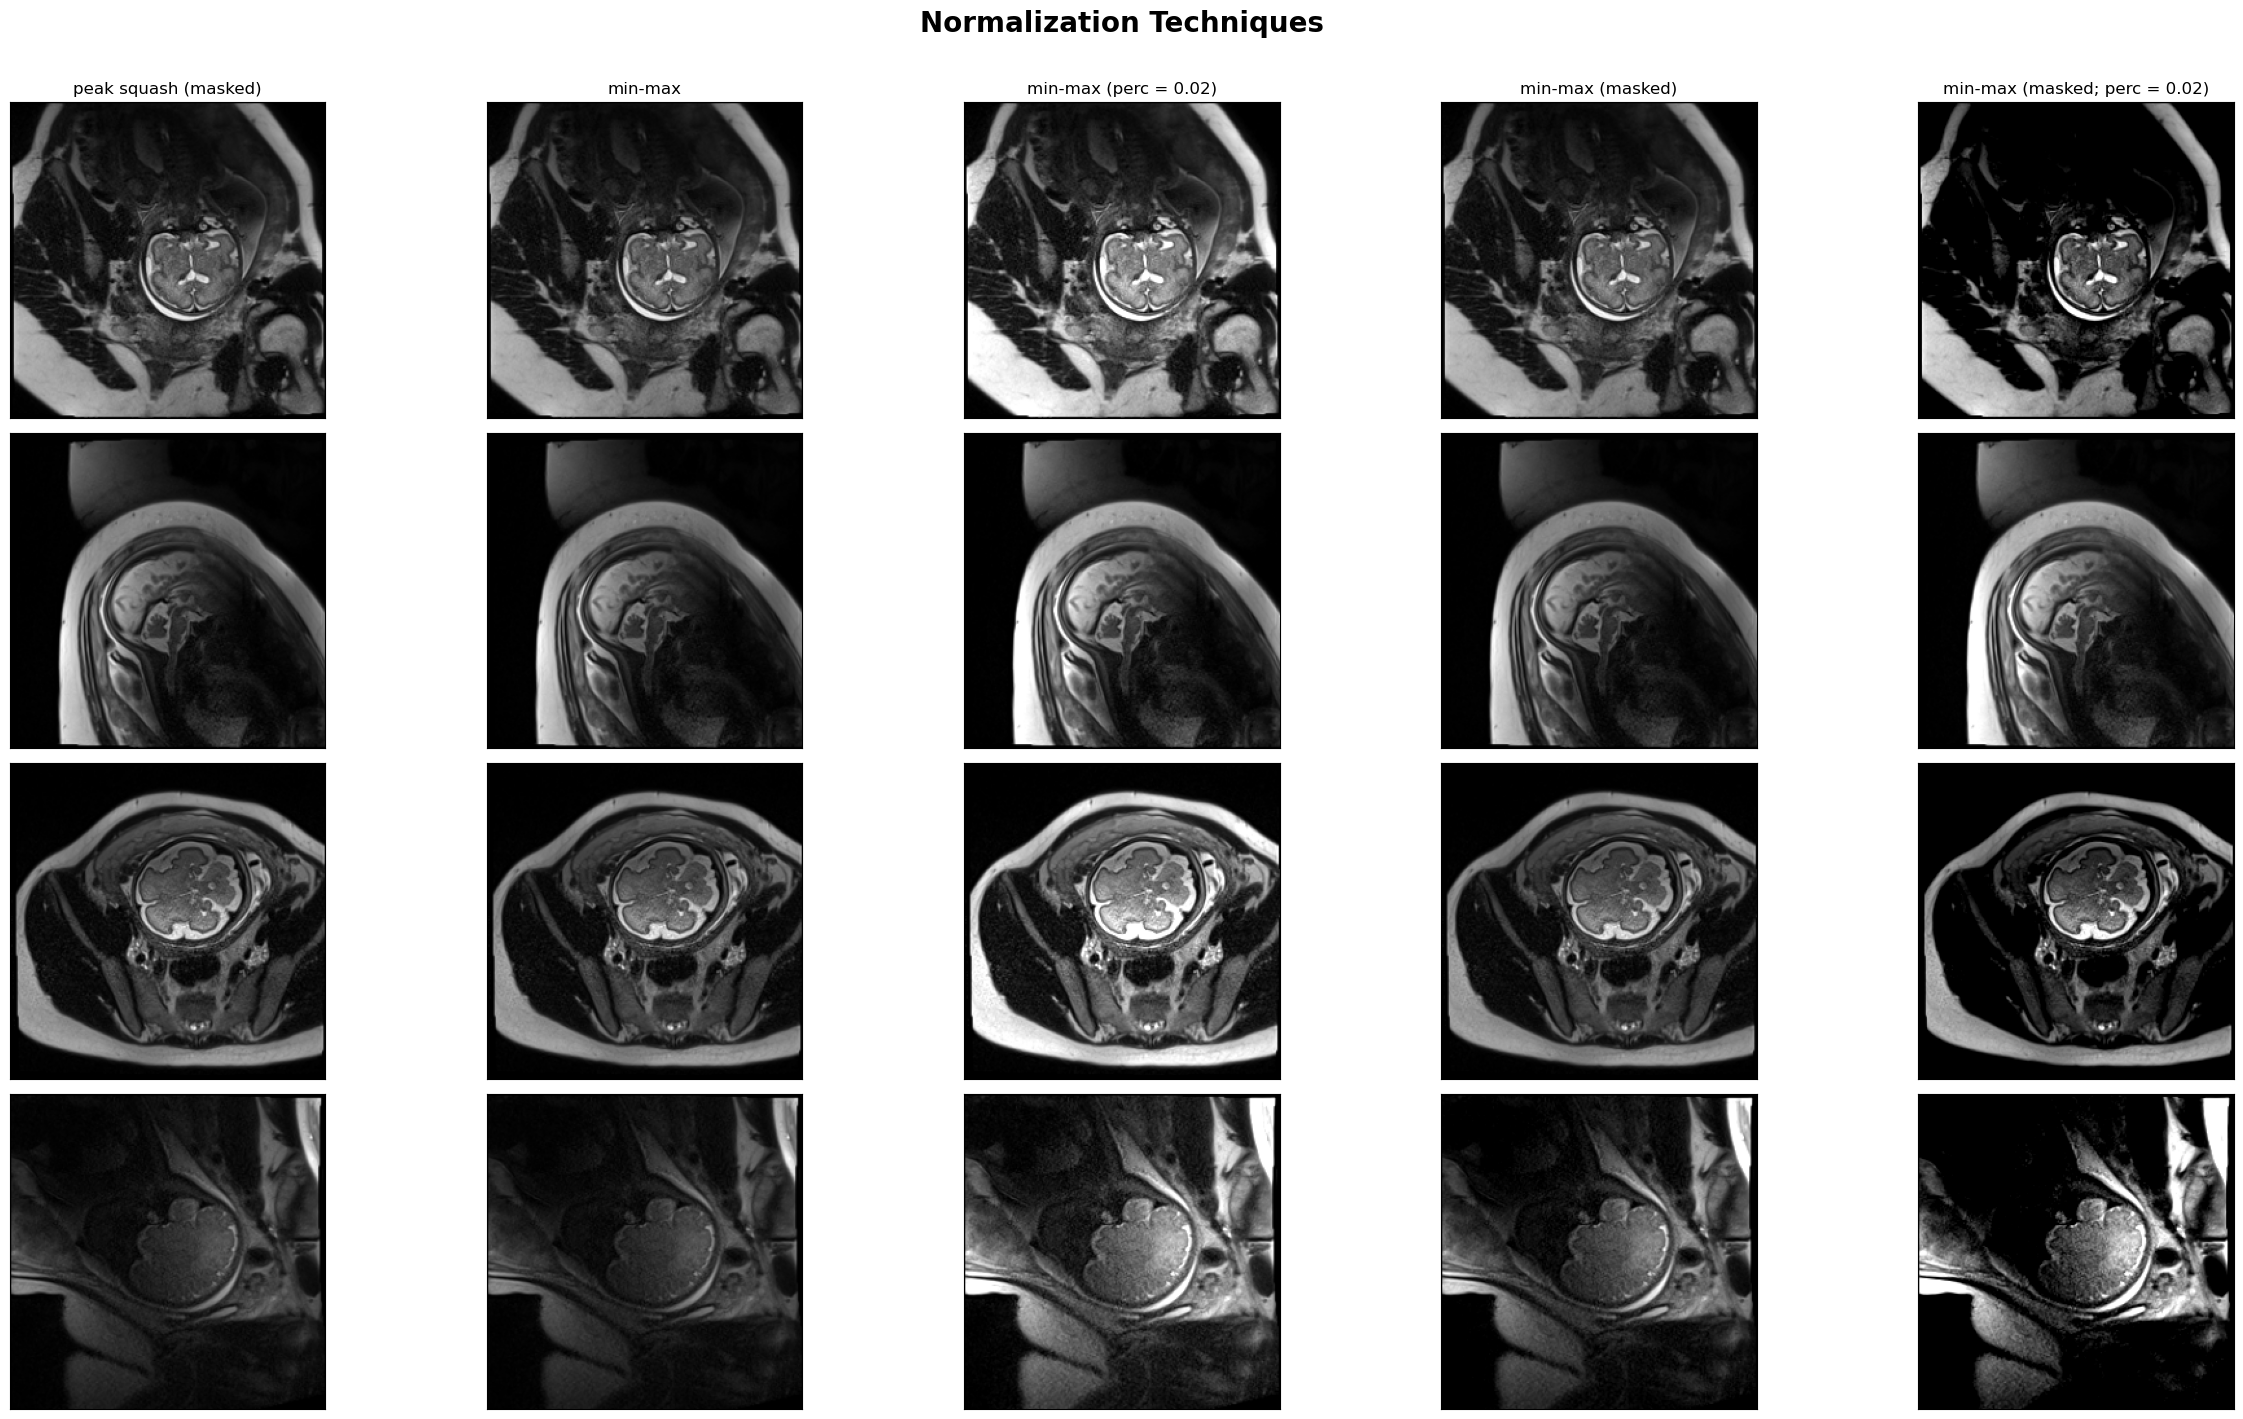

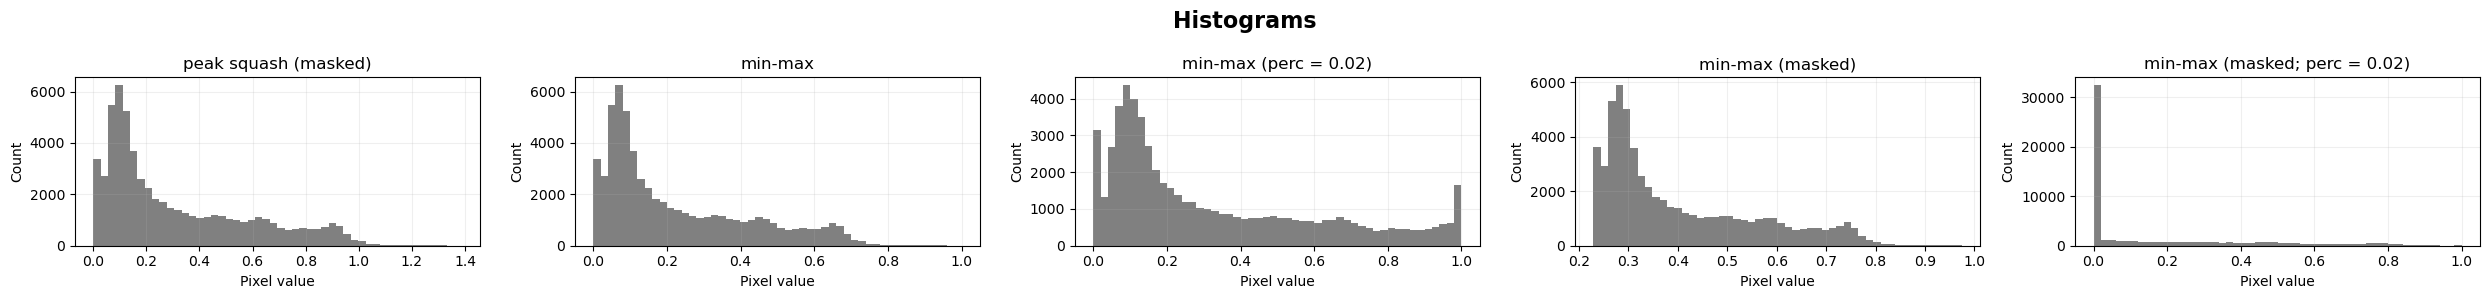

In [78]:
display_datasets(
    dataset = train_dataset,
    vp_dict_list = norm_params,
    idxs = idxs,
    sup_title = 'Normalization Techniques',
    fpath = Path('normalization.png'),
    hist_fpath=Path('normalization_hists.png')
)